<a href="https://colab.research.google.com/github/ssharmeela/Heart-Disease-Detection-/blob/main/ML_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📊 DATASET PREVIEW:
   age  salary  experience  loan amount  credit score  exp_loan  approvement
0   32   35952          19      8565729           394         2            0
1   33   49883          17      6213737           786         3            0
2   30   30183          15      5979051           571         1            0
3   53   34511           8      5926487           326         4            0
4   47   33984          19      6785298           590         2            0

📐 Table Shape: (1000, 7)

📊 LOAN APPROVAL DISTRIBUTION:
approvement
0    893
1    107
Name: count, dtype: int64

✅ Approval Rate: 10.7%

🎯 Model Accuracy: 97.50%

📄 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       181
           1       0.89      0.84      0.86        19

    accuracy                           0.97       200
   macro avg       0.94      0.92      0.93       200
weighted avg       0.97      0.97      0.97       200


🔍 

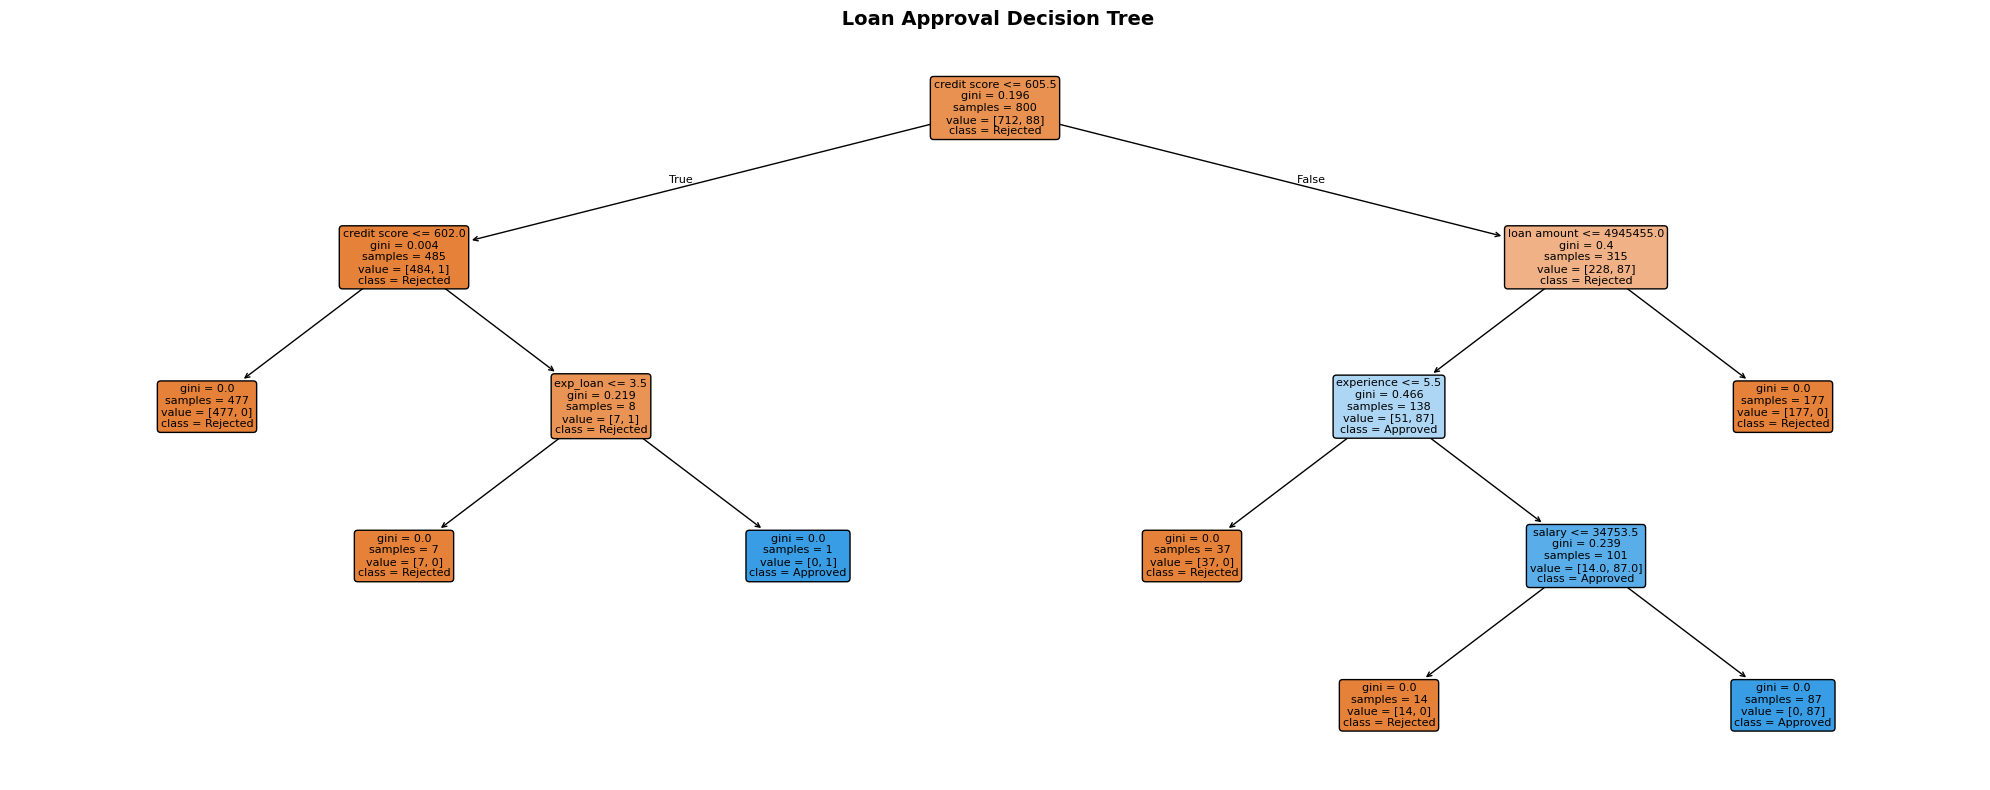

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# -----------------------------
# STEP 1: Generate Dataset
# -----------------------------
n = 1000
np.random.seed(24)

data = {
    "age": np.random.randint(30, 60, n),
    "salary": np.random.randint(30000, 60000, n),
    "experience": np.random.randint(0, 20, n),
    "loan amount": np.random.randint(500000, 10000000, n),
    "credit score": np.random.randint(300, 800, n),
    "exp_loan": np.random.randint(0, 5, n)
}

table = pd.DataFrame(data)

# Target variable (Loan Approval Logic)
table['approvement'] = (
    (table["salary"] > 35000) &
    (table["experience"] > 5) &
    (table["loan amount"] < 5000000) &
    (table["credit score"] > 600)
).astype(int)

# -----------------------------
# STEP 2: Explore Data
# -----------------------------
print("📊 DATASET PREVIEW:")
print(table.head())

print("\n📐 Table Shape:", table.shape)

print("\n📊 LOAN APPROVAL DISTRIBUTION:")
print(table["approvement"].value_counts())

print(f"\n✅ Approval Rate: {table['approvement'].mean() * 100:.1f}%")

# -----------------------------
# STEP 3: Train Model
# -----------------------------
X = table.drop('approvement', axis=1)
y = table['approvement']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

# -----------------------------
# STEP 4: Evaluate Model
# -----------------------------
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Model Accuracy: {accuracy * 100:.2f}%")

print("\n📄 Classification Report:")
print(classification_report(y_test, y_pred))

# -----------------------------
# STEP 5: Prediction Function
# -----------------------------
def predict_loan(age, salary, experience,
                 loan_amount, credit_score,
                 existing_loans):

    applicant = pd.DataFrame({
        'age': [age],
        'salary': [salary],
        'experience': [experience],
        'loan amount': [loan_amount],
        'credit score': [credit_score],
        'exp_loan': [existing_loans]
    })

    prediction = model.predict(applicant)[0]
    probability = model.predict_proba(applicant)[0]

    if prediction == 1:
        result = "✅ APPROVED"
    else:
        result = "❌ REJECTED"

    print("\n🔍 Prediction Result:")
    print("Status:", result)
    print(f"Confidence: {max(probability) * 100:.2f}%")

    return result, probability

# -----------------------------
# STEP 6: Test Prediction
# -----------------------------
predict_loan(40, 50000, 10, 3000000, 700, 1)


print("\n📊 FEATURE IMPORTANCE:")   # heading
print("="*40)                      # prints line like ======

# Create a table with feature names and their importance values
importance = pd.DataFrame({
    'Feature': X.columns,                    # column names (age, salary, etc.)
    'Importance': model.feature_importances_ # importance values from model
}).sort_values('Importance', ascending=False)  # sort from highest to lowest

# Loop through each row of the table
for _, row in importance.iterrows():

    # Create a bar using blocks (more blocks = more important feature)
    bar = '█' * int(row['Importance'] * 40)

    # Print feature name, bar, and importance value
    print(f"{row['Feature']:15} {bar} {row['Importance']:.4f}")

# Add at the very end

import matplotlib.pyplot as plt          # for plotting graphs
from sklearn.tree import plot_tree       # to draw decision tree

plt.figure(figsize=(20, 8))              # create big figure (size of image)

# Draw the decision tree
plot_tree(
    model,                               # your trained decision tree model
    feature_names=X.columns,              # names like age, salary, etc.
    class_names=['Rejected', 'Approved'],# output labels
    filled=True,                         # add colors
    rounded=True,                        # round the boxes
    fontsize=8                           # text size
)

# Add title to the graph
plt.title(" Loan Approval Decision Tree",
          fontsize=14, fontweight='bold')

plt.tight_layout()                       # adjust spacing properly

plt.savefig('loan_tree.png', dpi=150)    # save image as file

plt.show()                               # display the tree


📊 DATASET PREVIEW:
   age  gender  chest_pain  blood_pressure  cholesterol  blood_sugar  \
0   64       1           1             156          257            1   
1   33       1           0             109          170            0   
2   30       1           3             172          243            0   
3   53       1           1             110          159            1   
4   47       1           3             113          293            1   

   max_heart_rate  exercise_angina  heart_disease  
0             188                1              1  
1             176                1              0  
2              82                0              1  
3              73                0              0  
4             143                1              1  

📐 Shape: (500, 9)

❤️ HEART DISEASE DISTRIBUTION:
heart_disease
1    411
0     89
Name: count, dtype: int64

📉 Disease Rate: 82.2%

✅ Model Training Completed!

🔍 Predictions Done!

🎯 Accuracy: 1.00

📄 Classification Report:
          

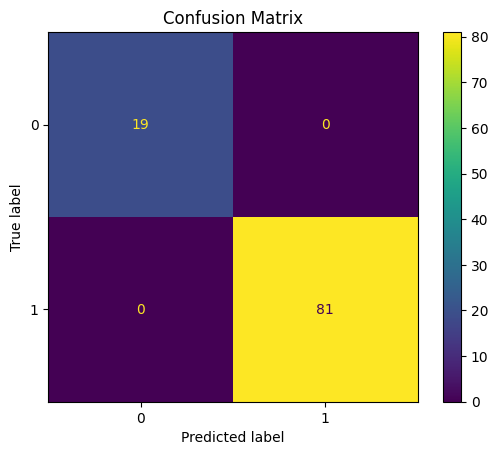


📊 Feature Importance:


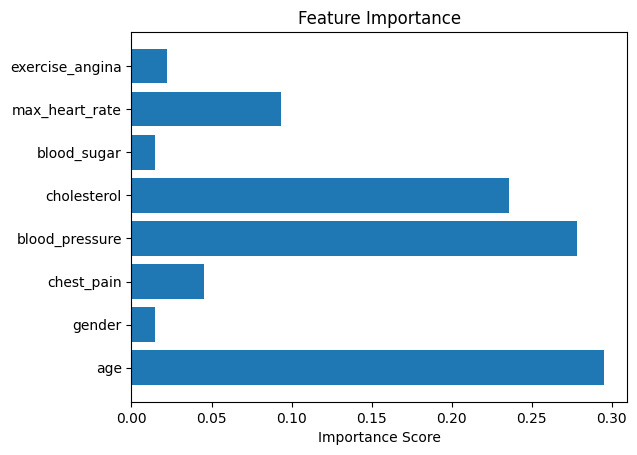



=== ❤️ CHECK YOUR HEART RISK ===


In [ ]:
# ============================================================
# ❤️ HEART DISEASE DETECTION USING RANDOM FOREST (SIMULATED DATA)
# ============================================================

# -----------------------------
# STEP 1: IMPORT LIBRARIES
# -----------------------------

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plot


# -----------------------------
# STEP 2: GENERATE DATASET
# -----------------------------

# Number of samples (patients)
n = 500

# Fix random values (same output every time)
np.random.seed(24)

# Create synthetic medical data
data = {
    'age': np.random.randint(30, 75, n),              # Age (30–75)
    'gender': np.random.randint(0, 2, n),             # 0=Female, 1=Male
    'chest_pain': np.random.randint(0, 4, n),         # Chest pain type (0–3)
    'blood_pressure': np.random.randint(90, 180, n),  # BP
    'cholesterol': np.random.randint(150, 350, n),    # Cholesterol
    'blood_sugar': np.random.randint(0, 2, n),        # 0=False, 1=True
    'max_heart_rate': np.random.randint(70, 200, n),  # Heart rate
    'exercise_angina': np.random.randint(0, 2, n),    # 1=Yes
}

# Convert to DataFrame
table = pd.DataFrame(data)


# -----------------------------
# STEP 3: CREATE TARGET COLUMN
# -----------------------------

# Logic to simulate heart disease
# If any risky condition → disease = 1

table['heart_disease'] = (
    (table['age'] > 55) |                         # Older age
    (table['blood_pressure'] > 140) |             # High BP
    (table['cholesterol'] > 280) |                # High cholesterol
    (
        (table['chest_pain'] > 2) &               # Severe chest pain
        (table['exercise_angina'] == 1)           # + angina
    )
).astype(int)


# -----------------------------
# STEP 4: DATA ANALYSIS
# -----------------------------

print("📊 DATASET PREVIEW:")
print(table.head())

print(f"\n📐 Shape: {table.shape}")

print("\n❤️ HEART DISEASE DISTRIBUTION:")
print(table['heart_disease'].value_counts())

print(f"\n📉 Disease Rate: {table['heart_disease'].mean()*100:.1f}%")


# -----------------------------
# STEP 5: SPLIT DATA
# -----------------------------

# Features (input)
X = table.drop('heart_disease', axis=1)

# Target (output)
y = table['heart_disease']

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# STEP 6: TRAIN MODEL
# -----------------------------

model = RandomForestClassifier(n_estimators=100) #use 100 decision tree

# Train model
model.fit(X_train, y_train)

print("\n✅ Model Training Completed!")


# -----------------------------
# STEP 7: PREDICTION
# -----------------------------

y_pred = model.predict(X_test)

print("\n🔍 Predictions Done!")


# -----------------------------
# STEP 8: EVALUATION
# -----------------------------

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Accuracy: {accuracy:.2f}")

# Classification report
print("\n📄 Classification Report:")
print(classification_report(y_test, y_pred))


# -----------------------------
# STEP 9: CONFUSION MATRIX
# -----------------------------

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plot.title("Confusion Matrix")
plot.show()


# -----------------------------
# STEP 10: FEATURE IMPORTANCE
# -----------------------------

importance = model.feature_importances_
features = X.columns

print("\n📊 Feature Importance:")
plot.figure()
plot.barh(features, importance)
plot.title("Feature Importance")
plot.xlabel("Importance Score")
plot.show()


# -----------------------------
# STEP 11: USER INPUT
# -----------------------------

print("\n\n=== ❤️ CHECK YOUR HEART RISK ===")

age = int(input("Enter Age: "))
gender = int(input("Enter Gender (1=Male, 0=Female): "))
chest_pain = int(input("Chest Pain (0-3): "))
bp = int(input("Blood Pressure: "))
chol = int(input("Cholesterol: "))
sugar = int(input("Blood Sugar (1=High, 0=Normal): "))
hr = int(input("Max Heart Rate: "))
angina = int(input("Exercise Angina (1=Yes, 0=No): "))

sample = [[age, gender, chest_pain, bp, chol, sugar, hr, angina]]

result = model.predict(sample)

if result[0] == 1:
    print("\n⚠️ High Risk of Heart Disease")
else:
    print("\n✅ Low Risk")


# ============================================================
# END OF PROJECT
# ============================================================